In [1]:
import os
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

from preprocess import load_image_data

In [2]:
img_images, img_labels = load_image_data()

print("Image shape:", img_images.shape)
print("Labels shape:", img_labels.shape)

Image shape: (3000, 128, 128, 3)
Labels shape: (3000,)


In [3]:
print("Min:", np.min(img_images))
print("Max:", np.max(img_images))
print("Labels:", np.unique(img_labels))

Min: 0.0
Max: 1.0
Labels: [0 1]


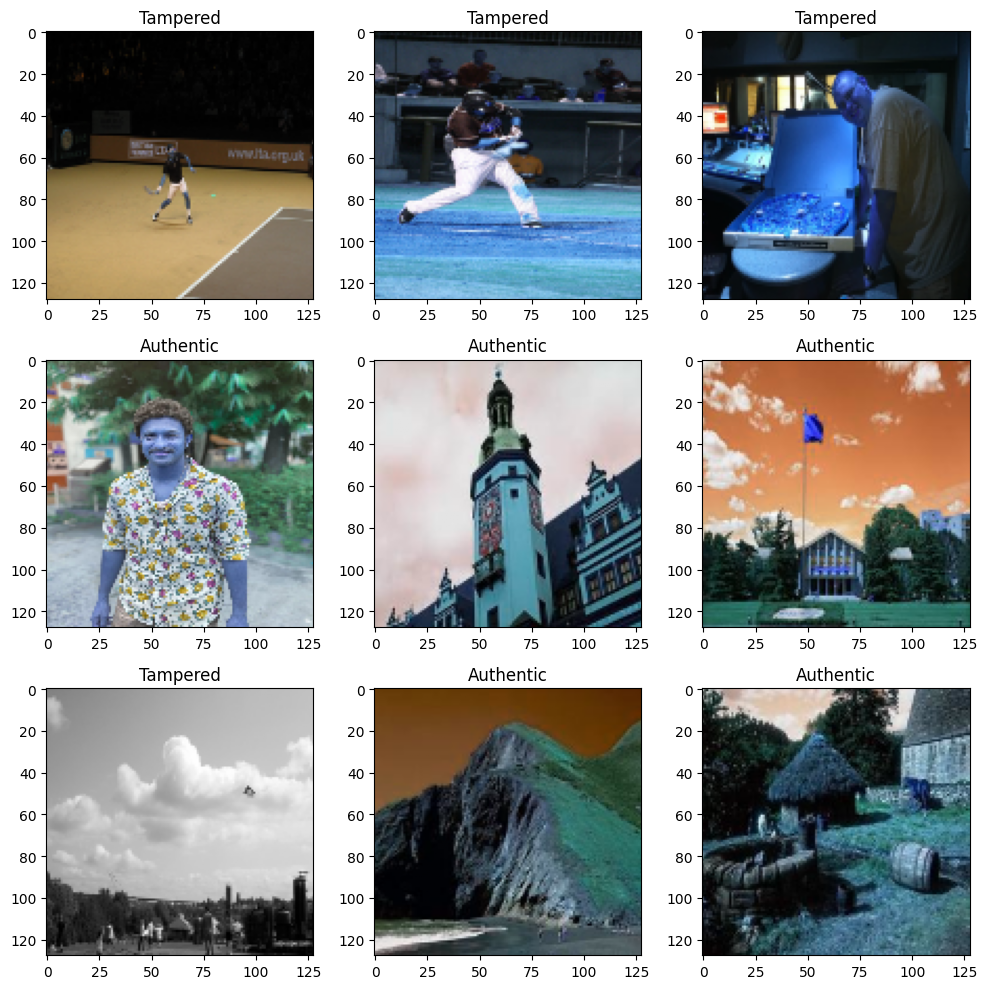

In [4]:
# guaranteed mix
auth_idx = [i for i in range(len(img_labels)) if img_labels[i]==0][:5]
tamp_idx = [i for i in range(len(img_labels)) if img_labels[i]==1][:4]

indices = auth_idx + tamp_idx
random.shuffle(indices)

plt.figure(figsize=(10,10))

for i in range(9):
    idx = indices[i]
    
    plt.subplot(3,3,i+1)
    plt.imshow(img_images[idx])
    plt.title("Authentic" if img_labels[idx]==0 else "Tampered")

plt.tight_layout()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    img_images, img_labels,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2400, 128, 128, 3)
Test: (600, 128, 128, 3)


In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# ===== BUILD FUNCTION =====
def build_model(base):
    base.trainable = False

    x = base.output
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base.input, outputs=out)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


# ===== LOAD BASE MODEL =====
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))

# ===== BUILD MODEL =====
vgg_model = build_model(vgg_base)

# ===== TRAIN =====
history_vgg = vgg_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_data=(X_test, y_test)
)

# ===== PRINT ACCURACY =====
print(f"\nVGG16 Final Accuracy: {history_vgg.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/5
150/150 [==============================] - 86s 572ms/step - loss: 0.6441 - accuracy: 0.6438 - val_loss: 0.5264 - val_accuracy: 0.7550
Epoch 2/5
150/150 [==============================] - 90s 602ms/step - loss: 0.4910 - accuracy: 0.7646 - val_loss: 0.5629 - val_accuracy: 0.6800
Epoch 3/5
150/150 [==============================] - 91s 609ms/step - loss: 0.4456 - accuracy: 0.7929 - val_loss: 0.5392 - val_accuracy: 0.7017
Epoch 4/5
150/150 [==============================] - 94s 629ms/step - loss: 0.3865 - accuracy: 0.8300 - val_loss: 0.4711 - val_accuracy: 0.7683
Epoch 5/5
150/150 [==============================] - 98s 657ms/step - loss: 0.3512 - accuracy: 0.8413 - val_loss: 0.5350 - val_accuracy: 0.7650

VGG16 Final Accuracy: 76.50%


In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# ===== LOAD BASE =====
res_base = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))

# ===== FREEZE MOST LAYERS =====
for layer in res_base.layers[:-10]:
    layer.trainable = False

for layer in res_base.layers[-10:]:
    layer.trainable = True

# ===== BUILD MODEL =====
x = res_base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)   # smaller dense
x = layers.Dropout(0.5)(x)
out = layers.Dense(1, activation='sigmoid')(x)

res_model = models.Model(inputs=res_base.input, outputs=out)

# 🔥 LOWER LEARNING RATE (VERY IMPORTANT)
res_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== TRAIN =====
history_res = res_model.fit(
    X_train, y_train,
    epochs=5,   # slightly more
    batch_size=16,
    validation_data=(X_test, y_test)
)

print(f"\nResNet50 Improved Accuracy: {history_res.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/5
150/150 [==============================] - 37s 232ms/step - loss: 0.6928 - accuracy: 0.5525 - val_loss: 0.7226 - val_accuracy: 0.5217
Epoch 2/5
150/150 [==============================] - 35s 236ms/step - loss: 0.6533 - accuracy: 0.6179 - val_loss: 0.6871 - val_accuracy: 0.5400
Epoch 3/5
150/150 [==============================] - 36s 242ms/step - loss: 0.6304 - accuracy: 0.6388 - val_loss: 0.6774 - val_accuracy: 0.5517
Epoch 4/5
150/150 [==============================] - 37s 245ms/step - loss: 0.6088 - accuracy: 0.6725 - val_loss: 0.6400 - val_accuracy: 0.6417
Epoch 5/5
150/150 [==============================] - 39s 258ms/step - loss: 0.5935 - accuracy: 0.6779 - val_loss: 0.8477 - val_accuracy: 0.5500

ResNet50 Improved Accuracy: 55.00%


In [9]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# ===== CNN MODEL =====
cnn_model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ===== EARLY STOPPING =====
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ===== TRAIN =====
history = cnn_model.fit(
    X_train, y_train,
    epochs=20,   # 🔥 more training
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# ===== PRINT ONLY ACCURACY =====
acc = history.history['val_accuracy'][-1]
print(f"\nCNN Accuracy: {acc*100:.2f}%")

Epoch 1/20
150/150 [==============================] - 14s 87ms/step - loss: 0.6963 - accuracy: 0.5183 - val_loss: 0.6928 - val_accuracy: 0.4967
Epoch 2/20
150/150 [==============================] - 13s 86ms/step - loss: 0.6805 - accuracy: 0.5779 - val_loss: 0.6682 - val_accuracy: 0.5783
Epoch 3/20
150/150 [==============================] - 13s 87ms/step - loss: 0.6643 - accuracy: 0.6042 - val_loss: 0.6424 - val_accuracy: 0.6117
Epoch 4/20
150/150 [==============================] - 13s 88ms/step - loss: 0.6229 - accuracy: 0.6600 - val_loss: 0.6235 - val_accuracy: 0.6417
Epoch 5/20
150/150 [==============================] - 14s 91ms/step - loss: 0.5941 - accuracy: 0.6992 - val_loss: 0.5643 - val_accuracy: 0.6917
Epoch 6/20
150/150 [==============================] - 13s 89ms/step - loss: 0.5086 - accuracy: 0.7763 - val_loss: 0.4074 - val_accuracy: 0.8433
Epoch 7/20
150/150 [==============================] - 14s 92ms/step - loss: 0.4484 - accuracy: 0.7929 - val_loss: 0.3544 - val_accuracy:

19/19 [==============================] - 1s 49ms/step


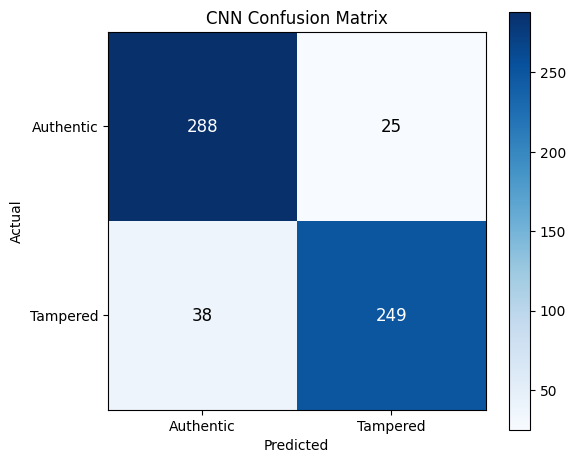

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ===== PREDICTIONS =====
y_pred = cnn_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# ===== CONFUSION MATRIX =====
cm = confusion_matrix(y_test, y_pred)

labels = ["Authentic", "Tampered"]

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.colorbar()

ticks = np.arange(len(labels))
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)

# numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black",
                 fontsize=12)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

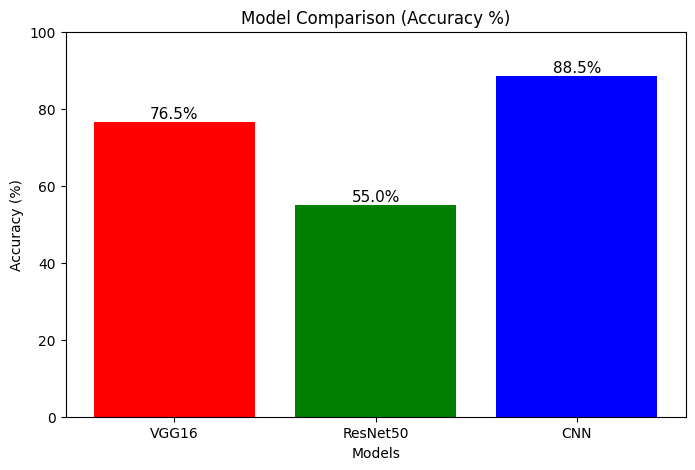

In [15]:
import matplotlib.pyplot as plt

# your final results
results = {
    "VGG16": 76.50,
    "ResNet50": 55.00,
    "CNN": 88.50
}

models = list(results.keys())
accuracies = list(results.values())

# RGB colors
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=colors)

# values on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11)

plt.title("Model Comparison (Accuracy %)")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

In [16]:
import os
os.makedirs("models", exist_ok=True)

cnn_model.save("models/image_model.h5")

print("Image model saved!")

Image model saved!
